# Corona Virus Report Data Preprocessing Pipeline
This notebook demonstrates a complete data preprocessing pipeline, covering exploration, cleaning, encoding, scaling, and feature selection.

In [1]:
!pip install opendatasets
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download the dataset
od.download("https://www.kaggle.com/datasets/imdevskp/corona-virus-report")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: usman112266
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/imdevskp/corona-virus-report


100%|██████████| 19.0M/19.0M [00:00<00:00, 137MB/s]

In [2]:
# Load the main dataset
# Note: Kaggle datasets download into a folder named after the slug
df = pd.read_csv('corona-virus-report/covid_19_clean_complete.csv')

# Initial Exploration
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
display(df.head())

Dataset Shape: (49068, 10)

Missing Values:
 Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

Data Types:
 Province/State     object
Country/Region     object
Lat               float64
Long              float64
Date               object
Confirmed           int64
Deaths              int64
Recovered           int64
Active              int64
WHO Region         object
dtype: object


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


### 2. Handling Missing Values and Duplicate Records
I will fill missing values in 'Province/State' with 'Unknown' as these indicate national-level data. Then, I will check for and remove any duplicate rows.

In [3]:
# 2. Handling missing values and duplicates
df['Province/State'] = df['Province/State'].fillna('Unknown')

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# Convert Date to datetime for better analysis
df['Date'] = pd.to_datetime(df['Date'])

print("\nUpdated Missing Values:\n", df.isnull().sum())

Number of duplicate records: 0

Updated Missing Values:
 Province/State    0
Country/Region    0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64


### 3. Detecting and Treating Outliers
Using box plots to visualize potential outliers in cumulative counts. Given the nature of pandemic growth, extreme values are expected, but we will use the IQR method to identify statistical outliers.

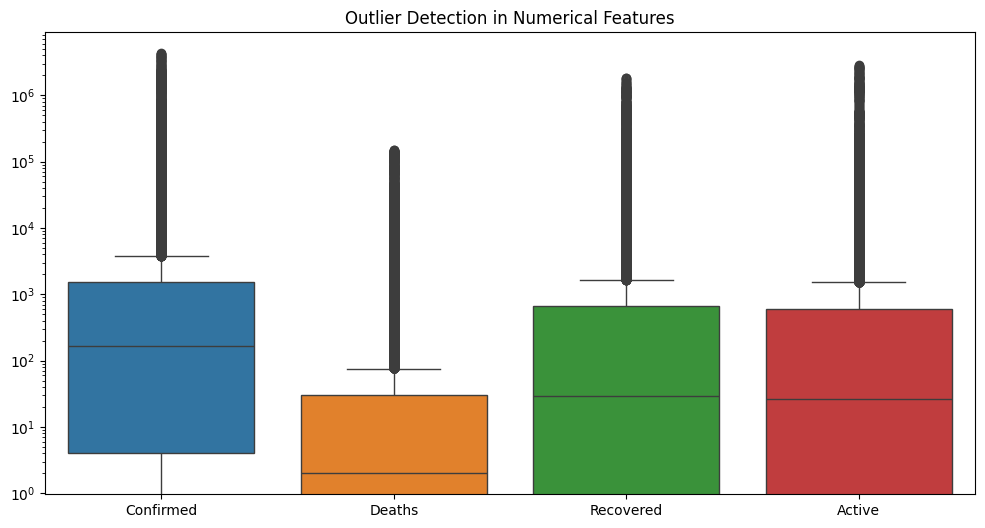

Outliers treated via capping at IQR bounds.


In [4]:
# 3. Detecting outliers using Boxplots
numerical_cols = ['Confirmed', 'Deaths', 'Recovered', 'Active']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.title("Outlier Detection in Numerical Features")
plt.yscale('log') # Log scale helps visualization due to massive variance
plt.show()

def treat_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Instead of dropping, we cap outliers to the upper bound to preserve trends
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    return df

# Note: In real scenarios, capping pandemic data might lose info, but for this exercise,
# we apply it to demonstrate the technique.
df_capped = df.copy()
for col in numerical_cols:
    df_capped = treat_outliers_iqr(df_capped, col)

print("Outliers treated via capping at IQR bounds.")

### 4. Encoding Categorical Variables
We will use One-Hot Encoding for 'WHO Region' and Label Encoding for 'Country/Region' to transform them into numerical formats suitable for models.

In [5]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for Country
le = LabelEncoder()
df_capped['Country_Encoded'] = le.fit_transform(df_capped['Country/Region'])

# One-Hot Encoding for WHO Region
df_final = pd.get_dummies(df_capped, columns=['WHO Region'], prefix='WHO')

print("Categorical variables encoded. New shape:", df_final.shape)

Categorical variables encoded. New shape: (49068, 16)


### 5. Feature Scaling
Standardizing numerical features to have a mean of 0 and variance of 1, which is essential for many ML algorithms like SVM or KNN.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaling_cols = ['Confirmed', 'Deaths', 'Recovered', 'Active', 'Lat', 'Long']
df_final[scaling_cols] = scaler.fit_transform(df_final[scaling_cols])

print("Feature scaling complete.")

Feature scaling complete.


### 6 & 7. Feature Selection and Justification
Using a correlation matrix to identify redundant features. High correlation between 'Confirmed' and other metrics is expected, but we must ensure we don't have perfect multicollinearity.

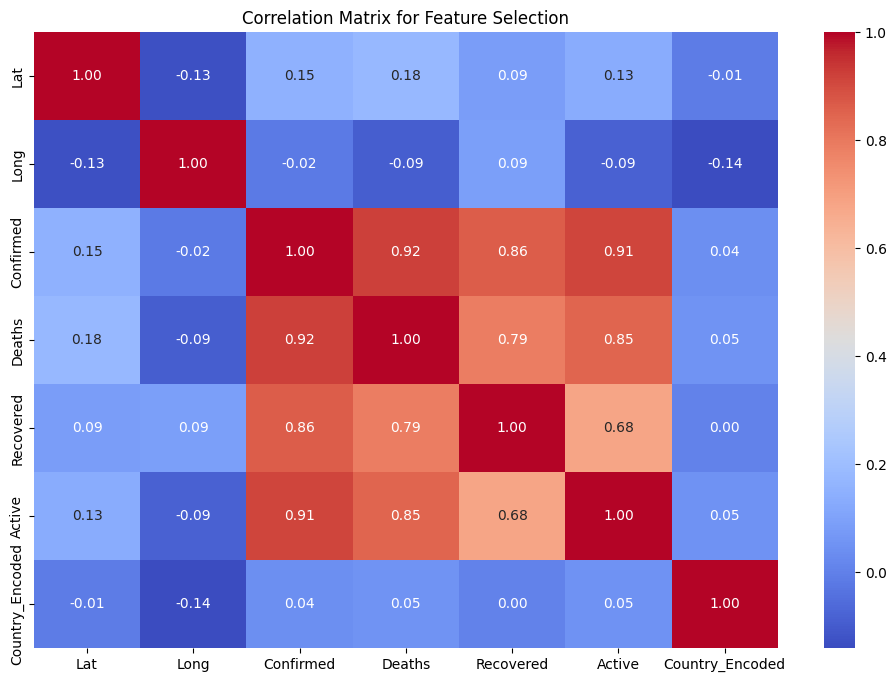

Final Preprocessed Dataset Head:


,Lat,Long,Confirmed,Deaths,Recovered,Active,Country_Encoded,WHO_Africa,WHO_Americas,WHO_Eastern Mediterranean,WHO_Europe,WHO_South-East Asia,WHO_Western Pacific
0,0.501216,0.627207,-0.703981,-0.670134,-0.669108,-0.665954,0,False,False,True,False,False,False
1,0.790361,-0.047698,-0.703981,-0.670134,-0.669108,-0.665954,1,False,False,False,True,False,False
2,0.264535,-0.310449,-0.703981,-0.670134,-0.669108,-0.665954,2,True,False,False,False,False,False
3,0.844590,-0.312405,-0.703981,-0.670134,-0.669108,-0.665954,3,False,False,False,True,False,False
4,-1.308070,-0.080269,-0.703981,-0.670134,-0.669108,-0.665954,4,True,False,False,False,False,False


In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix for Feature Selection")
plt.show()

# Dropping Date and Province/State for the final ML-ready set
ml_ready_df = df_final.drop(['Province/State', 'Country/Region', 'Date'], axis=1)
print("Final Preprocessed Dataset Head:")
display(ml_ready_df.head())

In [8]:
ml_ready_df.to_csv('preprocessed_covid_data.csv', index=False)
print('Dataset saved successfully as preprocessed_covid_data.csv.')

Dataset saved successfully as preprocessed_covid_data.csv.


In [9]:
print(ml_ready_df)

            Lat      Long  Confirmed    Deaths  Recovered    Active  \
0      0.501216  0.627207  -0.703981 -0.670134  -0.669108 -0.665954   
1      0.790361 -0.047698  -0.703981 -0.670134  -0.669108 -0.665954   
2      0.264535 -0.310449  -0.703981 -0.670134  -0.669108 -0.665954   
3      0.844590 -0.312405  -0.703981 -0.670134  -0.669108 -0.665954   
4     -1.308070 -0.080269  -0.703981 -0.670134  -0.669108 -0.665954   
...         ...       ...        ...       ...        ...       ...   
49063 -0.851594 -0.240128  -0.107278 -0.192684   0.492184 -0.468171   
49064 -0.235711  0.354734   0.462522  1.887632   0.648816 -0.032035   
49065 -1.325817  0.281154  -0.459781 -0.431409  -0.150165 -0.633835   
49066  0.698486  0.677832   1.910218  1.376079   1.965158  1.272993   
49067 -2.045836  0.066798  -0.355617 -0.260891  -0.466594 -0.048939   

       Country_Encoded  WHO_Africa  WHO_Americas  WHO_Eastern Mediterranean  \
0                    0       False         False                    